# Canada Food CPI Experiment

A faithful reproduction of the CFPR (Canada's Food Price Report) forecasting exercise.

**What this notebook does:**

1. Loads historical Canadian food CPI data and FRED macro covariates.
2. Runs rolling-origin backtests at **July 1 of each year** (2009–2024), fitting each
   predictor to all data available up to that date.
3. Forecasts a **12-step trajectory** (horizons 6–17 from the July origin = January through
   December of the following calendar year) — the window needed to compute an
   average-year-over-average-year (avg/avg) YoY CPI change.
4. Reports errors disaggregated by origin year and summarises CRPS and MAPE across origins.
5. Derives an avg/avg YoY prediction range for the most recent origin.
6. Runs a budget-limited protected evaluation on a held-out window.

**Fast-mode flag:** set `FAST_MODE = True` (default) to use quick-fitting predictors while
designing the notebook. Flip to `False` and add `DartsAutoARIMAPredictor` or
`DartsLightGBMPredictor` once you're ready for a full run.

---
## 1. Setup

In [1]:
from __future__ import annotations

import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# ── Repo root (works from implementations/experiments/food_price_forecasting/) ──
ROOT = Path.cwd().resolve().parents[2]

import sys
for p in [ROOT / "aieng-forecasting", ROOT / "implementations"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(ROOT / ".env")

from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters.fred import FREDAdapter
from aieng.forecasting.data.adapters.statcan import StatCanAdapter
from aieng.forecasting.evaluation.backtest import BacktestSpec, BacktestResult, multi_backtest, MultiTargetBacktestSpec
from aieng.forecasting.evaluation.eval import EvalTracker, MultiTargetEvalSpec, multi_evaluate
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask

from methods.darts_regression import DartsLinearRegressionPredictor
from methods.naive import LastValuePredictor
from methods.darts_arima import DartsAutoARIMAPredictor

print(f"Root: {ROOT}")

Root: /Users/ethanjackson/agentic-forecasting


In [2]:
# ── Experiment configuration ─────────────────────────────────────────────────

# Select one food CPI category to analyse. Options:
#   cpi_food_canada                     (overall food)
#   cpi_bakery_cereal_canada
#   cpi_dairy_eggs_canada
#   cpi_fish_seafood_canada
#   cpi_restaurants_canada
#   cpi_fruit_preparations_nuts_canada
#   cpi_meat_canada
#   cpi_other_food_nonalcoholic_canada
#   cpi_vegetables_preparations_canada
CATEGORY_ID = "cpi_food_canada"

# CFPR trajectory horizons: from a July 1 origin, horizon h points to
#   horizon  1 → August Y    (current year)
#   horizon  6 → January Y+1 (start of next calendar year)
#   horizon 17 → December Y+1 (end of next calendar year)
# Horizons 6–17 give the full Jan–Dec Y+1 window used in the avg/avg YoY calc.
TRAJECTORY_HORIZONS: list[int] = list(range(6, 18))

# Development flag — use lightweight predictors while iterating on the notebook.
# Set to False and add more predictors for a real experiment run.
FAST_MODE = False
NUM_SAMPLES = 100 if FAST_MODE else 500

# Backtest window: July 2009 → July 2024 (16 annual July origins).
BACKTEST_START = datetime(2009, 7, 1)
BACKTEST_END   = datetime(2024, 7, 1)

print(f"Category  : {CATEGORY_ID}")
print(f"Horizons  : {TRAJECTORY_HORIZONS[0]}–{TRAJECTORY_HORIZONS[-1]} ({len(TRAJECTORY_HORIZONS)} steps)")
print(f"Fast mode : {FAST_MODE}")

Category  : cpi_food_canada
Horizons  : 6–17 (12 steps)
Fast mode : False


---
## 2. Data loading

Run the data fetch scripts first if the cache is missing:

```bash
uv run python scripts/fetch_cpi.py   # Statistics Canada food CPI
uv run python scripts/fetch_fred.py  # FRED macro series
```

In [3]:
STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE    = ROOT / "data" / "fred"

STATCAN_TABLE = "18-10-0004-11"

# Each entry: (series_id, product_group_label, description, units)
# Labels must match the "Products and product groups" column in the StatCan CSV exactly.
STATCAN_SERIES: list[tuple[str, str, str, str]] = [
    ("cpi_food_canada",                    "Food",                                              "CPI Food (overall), Canada (2002=100)",                               "Index 2002=100"),
    ("cpi_bakery_cereal_canada",           "Bakery and cereal products (excluding baby food)",  "CPI Bakery and cereal products (excl. baby food), Canada (2002=100)",  "Index 2002=100"),
    ("cpi_dairy_eggs_canada",              "Dairy products and eggs",                            "CPI Dairy products and eggs, Canada (2002=100)",                      "Index 2002=100"),
    ("cpi_fish_seafood_canada",            "Fish, seafood and other marine products",             "CPI Fish, seafood and other marine products, Canada (2002=100)",      "Index 2002=100"),
    ("cpi_restaurants_canada",             "Food purchased from restaurants",                     "CPI Food purchased from restaurants, Canada (2002=100)",              "Index 2002=100"),
    ("cpi_fruit_preparations_nuts_canada", "Fruit, fruit preparations and nuts",                  "CPI Fruit, fruit preparations and nuts, Canada (2002=100)",           "Index 2002=100"),
    ("cpi_meat_canada",                    "Meat",                                                "CPI Meat, Canada (2002=100)",                                         "Index 2002=100"),
    ("cpi_other_food_nonalcoholic_canada", "Other food products and non-alcoholic beverages",     "CPI Other food and non-alcoholic beverages, Canada (2002=100)",       "Index 2002=100"),
    ("cpi_vegetables_preparations_canada", "Vegetables and vegetable preparations",                "CPI Vegetables and vegetable preparations, Canada (2002=100)",        "Index 2002=100"),
]

FRED_COVARIATES: list[tuple[str, str, str, str]] = [
    ("fred_us_cpi_food_at_home",            "CPIFABSL",        "US CPI: Food at Home",                "Index 1982-84=100"),
    ("fred_us_cpi_meats_poultry_fish_eggs", "CUSR0000SAF112",  "US CPI: Meats, Poultry, Fish & Eggs", "Index 1982-84=100"),
    ("fred_us_cpi_fruits_vegetables",        "CUSR0000SAF113",  "US CPI: Fruits & Vegetables",         "Index 1982-84=100"),
    ("fred_canada_10yr_bond_yield",          "IRLTLT01CAM156N", "Canada 10-year bond yield",           "% per annum"),
    ("fred_canada_us_exchange_rate",         "EXCAUS",           "Canada / US exchange rate",           "CAD per USD"),
]
COVARIATE_IDS: list[str] = [c[0] for c in FRED_COVARIATES]

svc = DataService()

# Each series needs its own adapter — StatCanAdapter is a single-series adapter
# that filters the table by GEO + product group label.
for series_id, product_group, description, units in STATCAN_SERIES:
    adapter = StatCanAdapter(
        table_id=STATCAN_TABLE,
        member_filter={"GEO": "Canada", "Products and product groups": product_group},
        cache_dir=STATCAN_CACHE,
    )
    svc.register(
        series_id,
        adapter,
        SeriesMetadata(series_id=series_id, description=description, source="Statistics Canada", units=units, frequency="MS"),
    )

# Each FRED series also needs its own adapter instance.
for series_id, fred_id, description, units in FRED_COVARIATES:
    svc.register(
        series_id,
        FREDAdapter(series_id=fred_id, cache_dir=FRED_CACHE),
        SeriesMetadata(series_id=series_id, description=description, source="FRED", units=units, frequency="MS"),
    )

print(f"Registered {len(STATCAN_SERIES)} StatCan + {len(FRED_COVARIATES)} FRED series.")

# Quick sanity check — as_of=now gives us the full uncut series for exploration
_now = datetime.now(tz=timezone.utc).replace(tzinfo=None)
target_df = svc.get_series(CATEGORY_ID, as_of=_now)
print(f"\n{CATEGORY_ID}: {target_df['timestamp'].min()} → {target_df['timestamp'].max()} ({len(target_df)} months)")

Registered 9 StatCan + 5 FRED series.

cpi_food_canada: 1949-01-01 00:00:00 → 2026-02-01 00:00:00 (926 months)


---
## 3. Data exploration

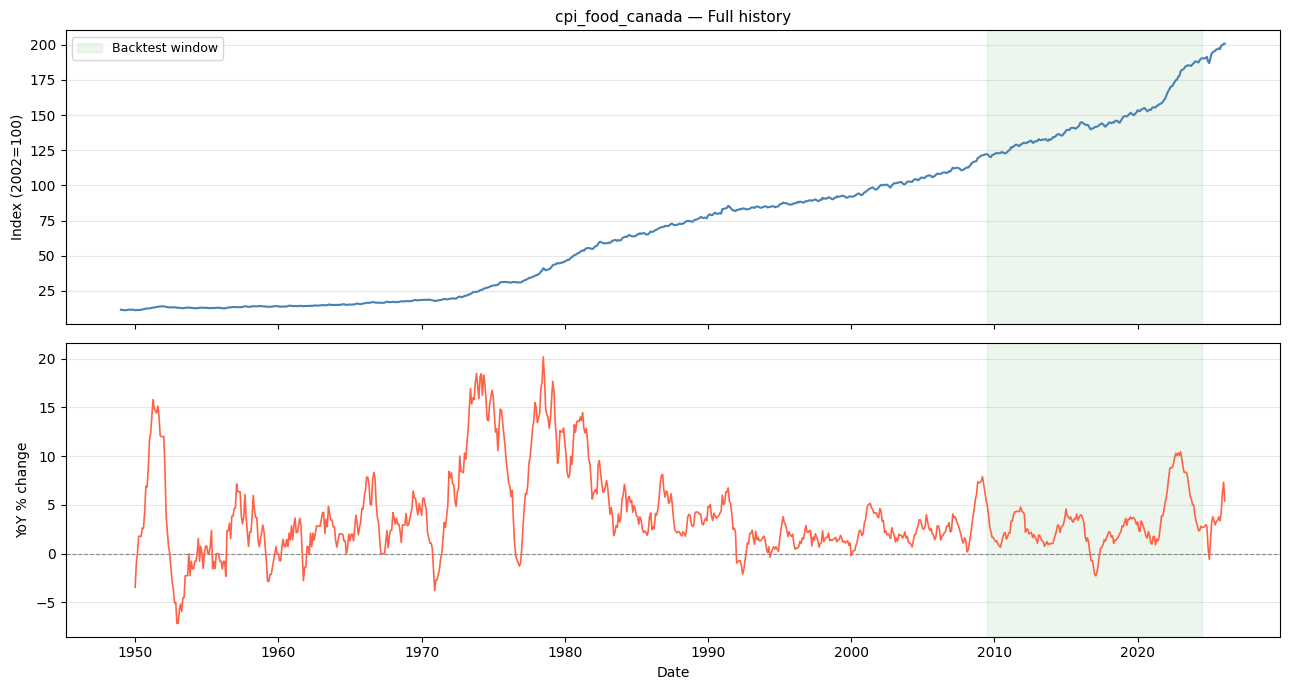

In [4]:
_now = datetime.now(tz=timezone.utc).replace(tzinfo=None)
target_df = svc.get_series(CATEGORY_ID, as_of=_now)
target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
target_df = target_df.set_index("timestamp").sort_index()

# Year-over-year change
target_df["yoy_pct"] = target_df["value"].pct_change(12) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(target_df.index, target_df["value"], color="steelblue", linewidth=1.5)
ax1.set_ylabel("Index (2002=100)", fontsize=10)
ax1.set_title(f"{CATEGORY_ID} — Full history", fontsize=11)
ax1.grid(axis="y", alpha=0.3)

ax2.axhline(0, color="#888", linewidth=0.8, linestyle="--")
ax2.plot(target_df.index, target_df["yoy_pct"], color="tomato", linewidth=1.2)
ax2.set_ylabel("YoY % change", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# Shade the CFPR backtest window
for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp(BACKTEST_START), pd.Timestamp(BACKTEST_END),
               alpha=0.07, color="green", label="Backtest window")

ax1.legend(fontsize=9)
plt.tight_layout()
plt.show()

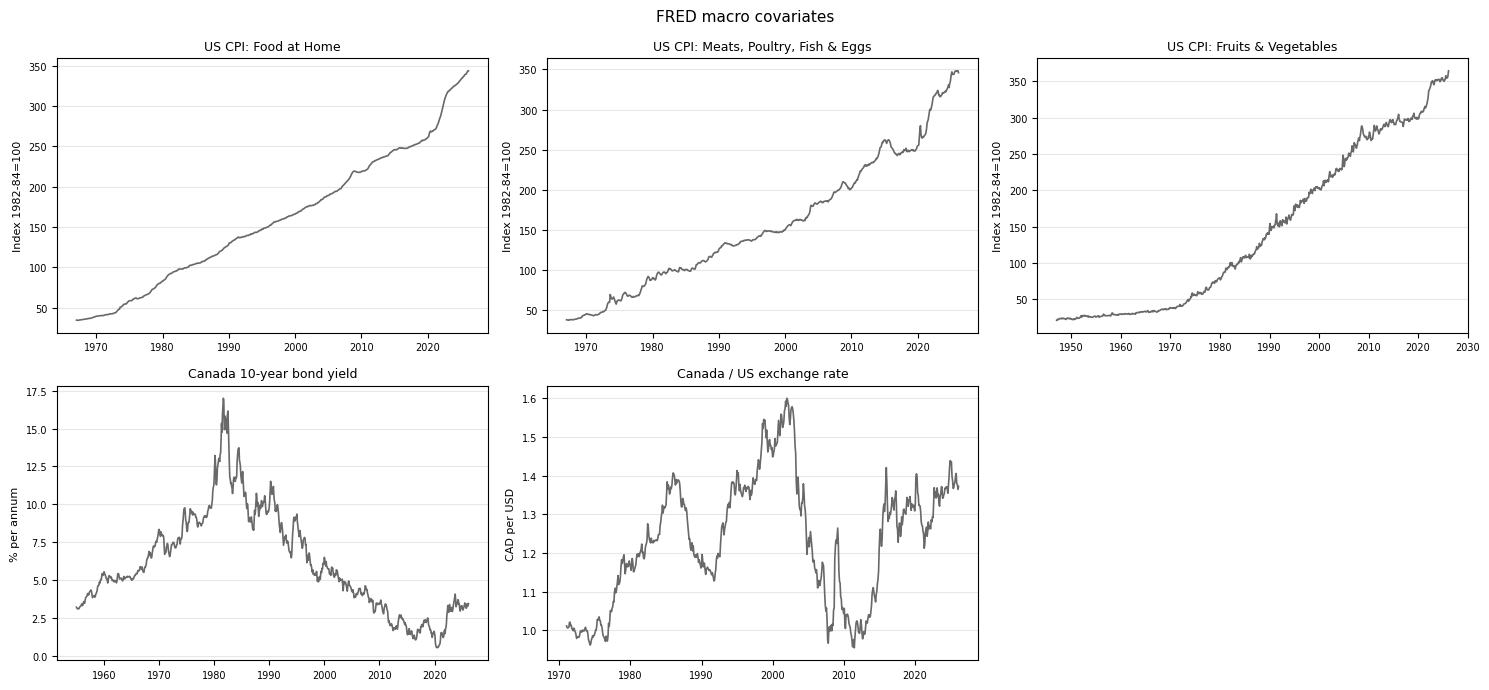

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes_flat = axes.flatten()

for ax, (series_id, _, description, units) in zip(axes_flat[:len(FRED_COVARIATES)], FRED_COVARIATES):
    df = svc.get_series(series_id, as_of=_now)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    ax.plot(df["timestamp"], df["value"], linewidth=1.2, color="dimgray")
    ax.set_title(description, fontsize=9)
    ax.set_ylabel(units, fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(labelsize=7)

axes_flat[-1].axis("off")  # hide the unused 6th panel
fig.suptitle("FRED macro covariates", fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. CFPR methodology

### The forecast origin: July 1

Statistics Canada's CPI data is released with a one-to-two month lag.  At the
time of forecast preparation (late July), the most recent available data point
is typically May or June.  We model this by setting the **forecast origin** to
**July 1 of each year**: the model sees all data up to June 30 and must predict
the future.

### The trajectory window

The CFPR's primary output is a statement like *"food prices are expected to
increase by 3–5% in 2026."*  This is an **average-year-over-average-year
(avg/avg) YoY change**:

$$\text{YoY}_{\text{avg/avg}} = \frac{\overline{\text{CPI}}_{Y+1}}{\overline{\text{CPI}}_{Y}} - 1$$

where $\overline{\text{CPI}}_Y = \frac{1}{12}\sum_{m=\text{Jan}}^{\text{Dec}} \text{CPI}_{Y,m}$.

From a **July origin** (year $Y$), the 12 monthly forecasts that cover year $Y+1$
correspond to horizons 6–17:

| Horizon | Forecast date |
|---------|---------------|
| 6       | January Y+1   |
| 7       | February Y+1  |
| …       | …             |
| 17      | December Y+1  |

We request **all 12 steps simultaneously** from each predictor.  Trajectory-based
models (Darts, and in future LLMs) produce this in a single call; the naive
baseline repeats its single value across all steps.

### Rolling-origin evaluation

We repeat this exercise for every July from 2009 to 2024 (16 origins).  Each
origin simulates the actual CFPR exercise for that year: the model is trained on
everything available up to July 1 of that year and then forecasts 12 months into
the following calendar year.  The **held-out eval window** (Jul 2021–Jul 2024) is
reserved for a budget-limited final assessment.

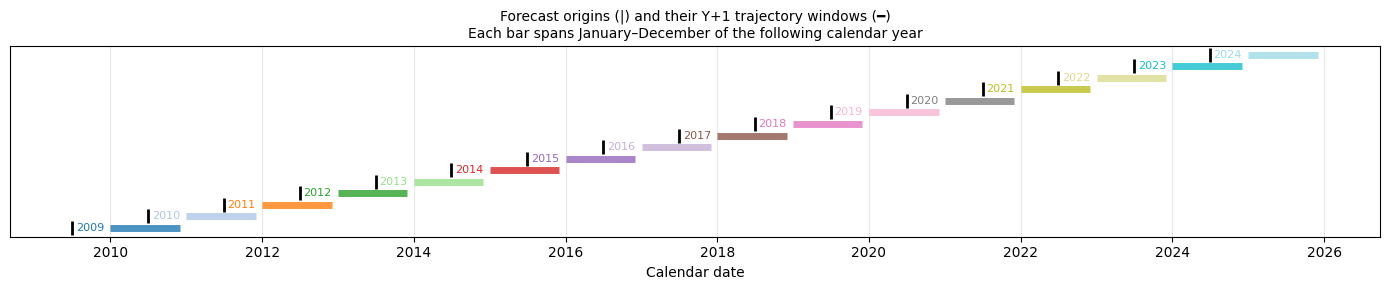


16 annual July origins: 2009-07-01 → 2024-07-01


In [6]:
origins = pd.date_range(start=BACKTEST_START, end=BACKTEST_END, freq="12MS")

fig, ax = plt.subplots(figsize=(14, 3))

cmap = plt.get_cmap("tab20", len(origins))
for i, origin in enumerate(origins):
    color = cmap(i)
    jan_y1 = origin + pd.DateOffset(months=6)
    dec_y1 = origin + pd.DateOffset(months=17)
    ax.hlines(i, jan_y1, dec_y1, linewidth=5, color=color, alpha=0.8)
    ax.plot(origin, i, "|", color="k", markersize=10, markeredgewidth=2)
    ax.text(jan_y1 - pd.DateOffset(months=1), i, str(origin.year), ha="right",
            va="center", fontsize=8, color=color)

ax.set_yticks([])
ax.set_xlabel("Calendar date")
ax.set_title(
    "Forecast origins (|) and their Y+1 trajectory windows (━)\n"
    "Each bar spans January–December of the following calendar year",
    fontsize=10,
)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\n{len(origins)} annual July origins: {origins[0].date()} → {origins[-1].date()}")

---
## 5. Predictors

Three predictors — all fast enough for iterative notebook development.
Swap in `DartsAutoARIMAPredictor` or `DartsLightGBMPredictor` when `FAST_MODE = False`.

In [7]:
predictors = [
    LastValuePredictor(),
    DartsAutoARIMAPredictor(),
    DartsLinearRegressionPredictor(
        lags=12,
        num_samples=NUM_SAMPLES,
    ),
    # Uncomment when FAST_MODE = False:
    # DartsLinearRegressionPredictor(
    #     lags=12,
    #     lags_past_covariates=12,
    #     covariate_series_ids=COVARIATE_IDS,
    #     num_samples=NUM_SAMPLES,
    # ),
]

_PALETTE = ["#7f7f7f", "#1f77b4", "#2ca02c"]
PREDICTOR_COLORS: dict[str, str] = {
    p.predictor_id: c for p, c in zip(predictors, _PALETTE)
}

for p in predictors:
    print(f"  {p.predictor_id}")

  last_value_naive
  darts_autoarima
  darts_linreg


---
## 6. Multi-horizon backtest

Each predictor is fitted once per origin and returns a **12-step trajectory**
(one `Prediction` per horizon step).  The harness scores each step independently
with CRPS against the eventually-observed value.

The backtest produces a flat list of predictions with shape
`16 origins × 12 horizons = 192` scored entries per predictor
(minus any future dates not yet observed).

In [8]:
# Build a BacktestSpec for the selected category with the CFPR trajectory horizons.
# We construct it directly rather than loading the reference YAML because the
# YAML uses horizons=[18] (single step); the trajectory version overrides that.
backtest_task = ForecastingTask(
    task_id=f"{CATEGORY_ID}_cfpr_trajectory",
    target_series_id=CATEGORY_ID,
    horizons=TRAJECTORY_HORIZONS,
    frequency="MS",
    description=(
        f"CFPR 12-step trajectory ({TRAJECTORY_HORIZONS[0]}–{TRAJECTORY_HORIZONS[-1]} months ahead) "
        f"for {CATEGORY_ID}, July origins."
    ),
)

backtest_spec = BacktestSpec(
    task=backtest_task,
    start=BACKTEST_START,
    end=BACKTEST_END,
    stride=12,  # annual July origins
    warmup=24,
)

print(f"Task: {backtest_task.task_id}")
print(f"Horizons: {backtest_task.horizons}")
print(f"Origins: {len(backtest_spec.origins())} annual July origins")

Task: cpi_food_canada_cfpr_trajectory
Horizons: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Origins: 16 annual July origins


In [9]:
from aieng.forecasting.evaluation.backtest import backtest

backtest_results: dict[str, BacktestResult] = {}
for predictor in predictors:
    print(f"Running {predictor.predictor_id} ...", end=" ", flush=True)
    backtest_results[predictor.predictor_id] = backtest(predictor, backtest_spec, svc)
    r = backtest_results[predictor.predictor_id]
    print(f"done. {len(r.predictions)} predictions scored, mean CRPS = {r.mean_crps:.4f}")

Running last_value_naive ... done. 192 predictions scored, mean CRPS = 4.3958
Running darts_autoarima ... 

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).


done. 192 predictions scored, mean CRPS = 2.5175
Running darts_linreg ... done. 192 predictions scored, mean CRPS = 2.2599


---
## 7. Forecast trajectories

For the **three most recent origins**, show the actual CPI series alongside the
fan chart for each predictor's 12-step trajectory.

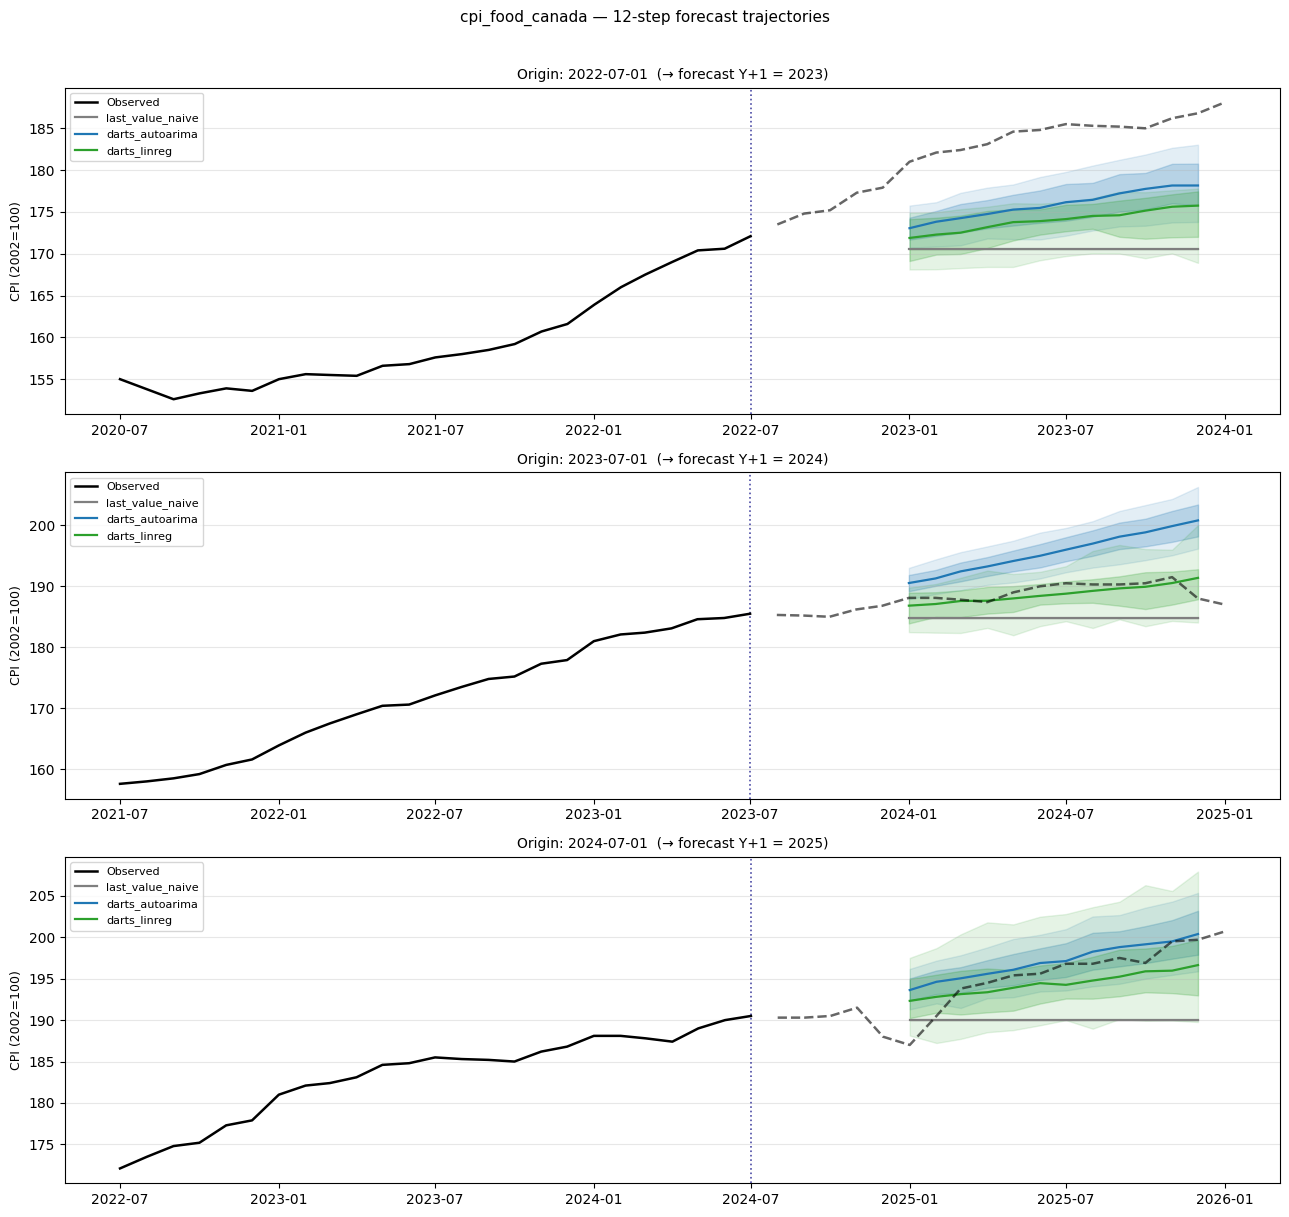

In [10]:
import matplotlib.patches as mpatches

# Get origin dates from backtest results (using first predictor's predictions)
all_origins_dt = sorted(set(
    p.as_of for p in next(iter(backtest_results.values())).predictions
))
recent_origins = all_origins_dt[-3:]  # 3 most recent

fig, axes = plt.subplots(len(recent_origins), 1, figsize=(13, 4 * len(recent_origins)), sharex=False)
if len(recent_origins) == 1:
    axes = [axes]

# Full actual series for context
actual_df = svc.get_series(CATEGORY_ID, as_of=_now)
actual_df["timestamp"] = pd.to_datetime(actual_df["timestamp"])

for ax, origin in zip(axes, recent_origins):
    origin_ts = pd.Timestamp(origin)
    # Show 24 months of history before origin
    hist_start = origin_ts - pd.DateOffset(months=24)
    hist = actual_df[(actual_df["timestamp"] >= hist_start) & (actual_df["timestamp"] <= origin_ts)]
    ax.plot(hist["timestamp"], hist["value"], color="k", linewidth=1.8, label="Observed", zorder=5)

    # Actual for the forecast window
    traj_end = origin_ts + pd.DateOffset(months=TRAJECTORY_HORIZONS[-1] + 1)
    fut_actual = actual_df[(actual_df["timestamp"] > origin_ts) & (actual_df["timestamp"] <= traj_end)]
    ax.plot(fut_actual["timestamp"], fut_actual["value"], color="k", linewidth=1.8,
            linestyle="--", alpha=0.6, zorder=4)

    for pid, color in PREDICTOR_COLORS.items():
        result = backtest_results[pid]
        # Predictions from this origin, ordered by forecast_date
        preds = sorted(
            [p for p in result.predictions if p.as_of == origin],
            key=lambda p: p.forecast_date,
        )
        if not preds:
            continue

        dates = [p.forecast_date for p in preds]
        medians = [p.payload.point_forecast for p in preds]
        q05 = [p.payload.quantiles[0.05] for p in preds]
        q25 = [p.payload.quantiles[0.20] for p in preds]
        q75 = [p.payload.quantiles[0.80] for p in preds]
        q95 = [p.payload.quantiles[0.95] for p in preds]

        ax.fill_between(dates, q05, q95, alpha=0.12, color=color)
        ax.fill_between(dates, q25, q75, alpha=0.22, color=color)
        ax.plot(dates, medians, color=color, linewidth=1.6, label=pid)

    ax.axvline(origin_ts, color="navy", linewidth=1.2, linestyle=":", alpha=0.7)
    ax.set_title(f"Origin: {origin_ts.date()}  (→ forecast Y+1 = {origin_ts.year + 1})", fontsize=10)
    ax.set_ylabel("CPI (2002=100)", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

plt.suptitle(f"{CATEGORY_ID} — 12-step forecast trajectories", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Average-year YoY analysis

The CFPR's headline metric is the **average-year-over-average-year YoY change**:

$$\text{YoY}_{\text{avg/avg}} = \frac{\overline{\hat{\text{CPI}}}_{Y+1}}{\overline{\text{CPI}}_{Y}} - 1$$

where:

- $\overline{\hat{\text{CPI}}}_{Y+1}$ = mean of the **predicted** index for Jan–Dec of Y+1
  (horizons 6–17 from the July origin).
- $\overline{\text{CPI}}_{Y}$ = mean of the **observed** index for Jan–Dec of Y
  (fully known at backtest time).

For each origin we compute this from the 12-step trajectory.  We can also derive
a **prediction interval** by computing the avg/avg YoY at each quantile level
independently.

In [11]:
def compute_avgyoy(
    result: BacktestResult,
    actual_df: pd.DataFrame,
) -> pd.DataFrame:
    """Compute avg/avg YoY for every origin in a BacktestResult.

    Parameters
    ----------
    result : BacktestResult
        Must contain predictions covering the Jan–Dec window of the year
        following each origin (i.e. TRAJECTORY_HORIZONS = range(6,18)).
    actual_df : pd.DataFrame
        Full observed series with 'timestamp' and 'value' columns.

    Returns
    -------
    pd.DataFrame
        One row per origin with columns: origin_year, actual_avg_y0,
        predicted_avg_y1, yoy_median, yoy_q05, yoy_q25, yoy_q75, yoy_q95,
        actual_yoy (NaN if actual Y+1 data not yet available).
    """
    actual_df = actual_df.copy()
    actual_df["timestamp"] = pd.to_datetime(actual_df["timestamp"])
    actual_df["year"] = actual_df["timestamp"].dt.year

    rows = []
    for origin in sorted(set(p.as_of for p in result.predictions)):
        origin_ts = pd.Timestamp(origin)
        origin_year = origin_ts.year
        next_year = origin_year + 1

        # Observed avg for year Y (Jan–Dec, should all be in the past)
        y0_vals = actual_df[actual_df["year"] == origin_year]["value"]
        if len(y0_vals) < 12:
            continue  # incomplete year, skip
        actual_avg_y0 = y0_vals.mean()

        # Predictions for the Jan–Dec window of Y+1
        traj_preds = [
            p for p in result.predictions
            if p.as_of == origin and pd.Timestamp(p.forecast_date).year == next_year
        ]
        if not traj_preds:
            continue

        medians = [p.payload.point_forecast for p in traj_preds]
        predicted_avg_y1_median = np.mean(medians)

        # Per-quantile avg/avg YoY
        def avg_yoy_at_q(q: float) -> float:
            qs = [p.payload.quantiles.get(q, p.payload.point_forecast) for p in traj_preds]
            return np.mean(qs) / actual_avg_y0 - 1

        # Actual Y+1 average (may not be available for most recent origins)
        y1_vals = actual_df[actual_df["year"] == next_year]["value"]
        actual_yoy = (y1_vals.mean() / actual_avg_y0 - 1) if len(y1_vals) == 12 else float("nan")

        rows.append({
            "origin_year": origin_year,
            "actual_avg_y0": actual_avg_y0,
            "predicted_avg_y1": predicted_avg_y1_median,
            "yoy_median": predicted_avg_y1_median / actual_avg_y0 - 1,
            "yoy_q05": avg_yoy_at_q(0.05),
            "yoy_q25": avg_yoy_at_q(0.20),
            "yoy_q75": avg_yoy_at_q(0.80),
            "yoy_q95": avg_yoy_at_q(0.95),
            "actual_yoy": actual_yoy,
        })

    return pd.DataFrame(rows)


yoy_by_predictor: dict[str, pd.DataFrame] = {}
for pid, result in backtest_results.items():
    yoy_by_predictor[pid] = compute_avgyoy(result, actual_df.reset_index())
    print(f"{pid}: {len(yoy_by_predictor[pid])} origins with avg/avg YoY")

last_value_naive: 16 origins with avg/avg YoY
darts_autoarima: 16 origins with avg/avg YoY
darts_linreg: 16 origins with avg/avg YoY


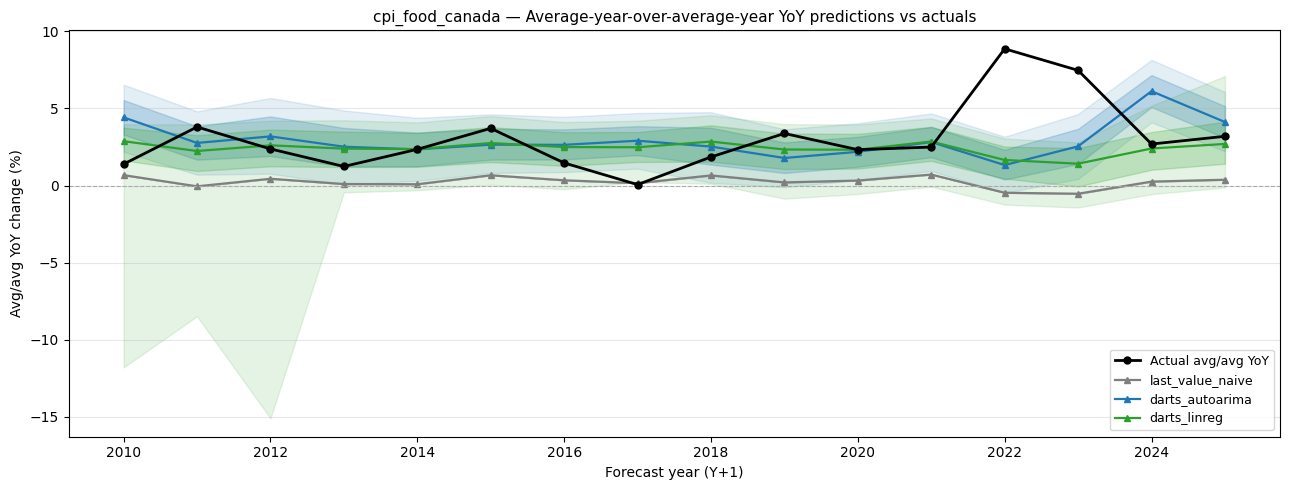

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

# Plot actual YoY (same for all predictors)
first_pid = list(yoy_by_predictor.keys())[0]
df_actual = yoy_by_predictor[first_pid]
ax.plot(
    df_actual["origin_year"] + 1,  # Y+1 is the year being described
    df_actual["actual_yoy"] * 100,
    color="k", linewidth=2, marker="o", markersize=5, label="Actual avg/avg YoY", zorder=5,
)

for pid, color in PREDICTOR_COLORS.items():
    df = yoy_by_predictor[pid]
    years = df["origin_year"] + 1
    ax.fill_between(years, df["yoy_q05"] * 100, df["yoy_q95"] * 100,
                    alpha=0.12, color=color)
    ax.fill_between(years, df["yoy_q25"] * 100, df["yoy_q75"] * 100,
                    alpha=0.22, color=color)
    ax.plot(years, df["yoy_median"] * 100, color=color, linewidth=1.6,
            marker="^", markersize=5, label=pid)

ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax.set_xlabel("Forecast year (Y+1)", fontsize=10)
ax.set_ylabel("Avg/avg YoY change (%)", fontsize=10)
ax.set_title(
    f"{CATEGORY_ID} — Average-year-over-average-year YoY predictions vs actuals",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Disaggregated error analysis

CRPS aggregated over all (origin, horizon) pairs gives a single number per
predictor. Here we break it down two ways:

1. **By origin year** — how did each predictor perform for each year's forecast?
2. **By horizon** — does accuracy degrade at longer horizons (as expected)?

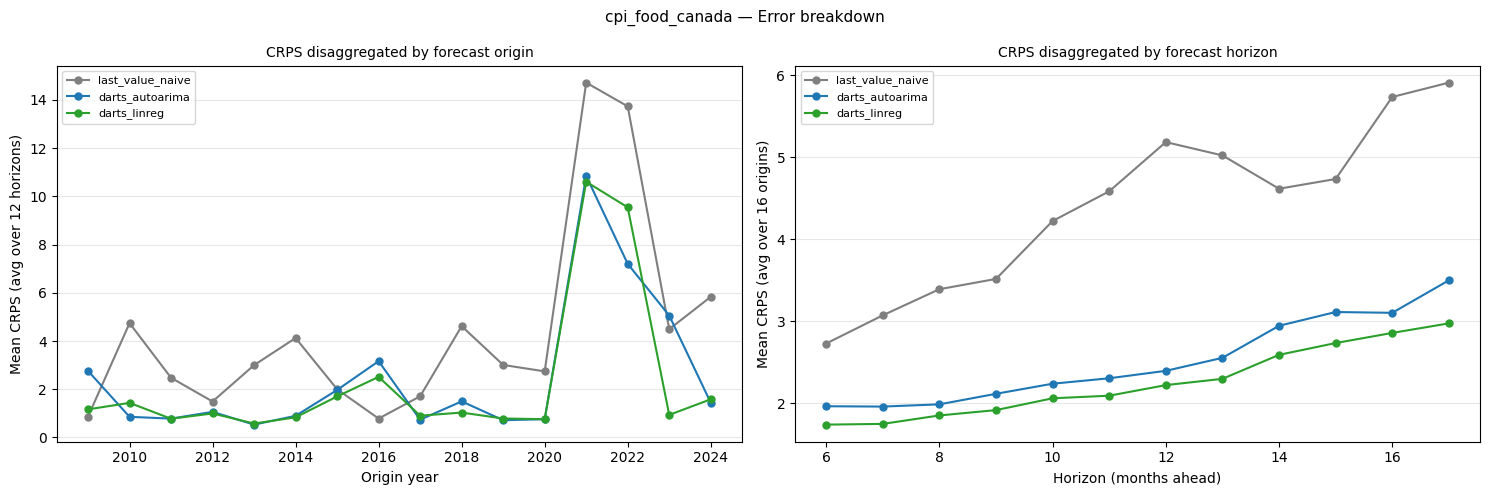

In [13]:
def results_to_df(result: BacktestResult, pid: str) -> pd.DataFrame:
    """Flatten BacktestResult predictions + scores into a tidy DataFrame."""
    rows = []
    for pred, score in zip(result.predictions, result.scores):
        fd = pd.Timestamp(pred.forecast_date)
        aof = pd.Timestamp(pred.as_of)
        horizon_months = (fd.year - aof.year) * 12 + (fd.month - aof.month)
        rows.append({
            "predictor_id": pid,
            "origin_year": aof.year,
            "horizon": horizon_months,
            "forecast_date": fd,
            "median": pred.payload.point_forecast,
            "crps": score,
        })
    return pd.DataFrame(rows)

all_preds_df = pd.concat(
    [results_to_df(result, pid) for pid, result in backtest_results.items()],
    ignore_index=True,
)

# Mean CRPS per (predictor, origin_year)
crps_by_origin = all_preds_df.groupby(["predictor_id", "origin_year"])["crps"].mean().unstack(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: CRPS by origin year
ax = axes[0]
for pid, color in PREDICTOR_COLORS.items():
    if pid in crps_by_origin:
        ax.plot(crps_by_origin.index, crps_by_origin[pid],
                color=color, linewidth=1.5, marker="o", markersize=5, label=pid)
ax.set_xlabel("Origin year", fontsize=10)
ax.set_ylabel("Mean CRPS (avg over 12 horizons)", fontsize=10)
ax.set_title("CRPS disaggregated by forecast origin", fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Right: CRPS by horizon
crps_by_horizon = all_preds_df.groupby(["predictor_id", "horizon"])["crps"].mean().unstack(0)
ax = axes[1]
for pid, color in PREDICTOR_COLORS.items():
    if pid in crps_by_horizon:
        ax.plot(crps_by_horizon.index, crps_by_horizon[pid],
                color=color, linewidth=1.5, marker="o", markersize=5, label=pid)
ax.set_xlabel("Horizon (months ahead)", fontsize=10)
ax.set_ylabel("Mean CRPS (avg over 16 origins)", fontsize=10)
ax.set_title("CRPS disaggregated by forecast horizon", fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"{CATEGORY_ID} — Error breakdown", fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. CRPS summary

In [14]:
# CRPS summary: mean per predictor, broken down by origin year
crps_pivot = (
    all_preds_df
    .groupby(["predictor_id", "origin_year"])["crps"].mean()
    .unstack("predictor_id")
    .round(4)
)
crps_pivot.loc["MEAN"] = crps_pivot.mean()

print("=== Mean CRPS per origin year (lower is better) ===")
print(crps_pivot.to_string())
print()

# Overall mean
overall = {pid: r.mean_crps for pid, r in backtest_results.items()}
print("Overall mean CRPS:")
for pid, v in overall.items():
    print(f"  {pid:40s}  {v:.4f}")

=== Mean CRPS per origin year (lower is better) ===
predictor_id  darts_autoarima  darts_linreg  last_value_naive
origin_year                                                  
2009                 2.759800      1.166000          0.866700
2010                 0.856400      1.435600          4.741700
2011                 0.782600      0.776800          2.475000
2012                 1.061300      0.996300          1.491700
2013                 0.533000      0.577900          3.000000
2014                 0.897700      0.835800          4.125000
2015                 1.969200      1.700800          2.000000
2016                 3.165600      2.513300          0.783300
2017                 0.737100      0.904100          1.708300
2018                 1.496900      1.032800          4.616700
2019                 0.716100      0.786900          3.008300
2020                 0.757500      0.759400          2.741700
2021                10.846900     10.606500         14.716700
2022              

---
## 11. MAPE analysis

MAPE uses the **median** forecast as a point estimate.  We compute:

$$\text{MAPE}_h = \left|\frac{\hat{\text{CPI}}_h - \text{CPI}_h}{\text{CPI}_h}\right| \times 100$$

and then average across horizons within each origin.

=== Mean APE (%) per origin year (lower is better) ===
predictor_id  darts_autoarima  darts_linreg  last_value_naive
origin_year                                                  
2009                  2.99000      1.467000            0.7030
2010                  1.00700      1.498000            3.7000
2011                  0.80800      0.490000            1.8910
2012                  1.27500      1.169000            1.1260
2013                  0.39500      0.469000            2.2060
2014                  1.02000      0.917000            2.9310
2015                  1.86000      1.757000            1.3930
2016                  2.84800      2.423000            0.5490
2017                  0.66400      0.982000            1.1720
2018                  1.53800      1.007000            3.0690
2019                  0.67800      0.734000            1.9550
2020                  0.66800      0.662000            1.7240
2021                  6.88700      6.585000            8.5240
2022           

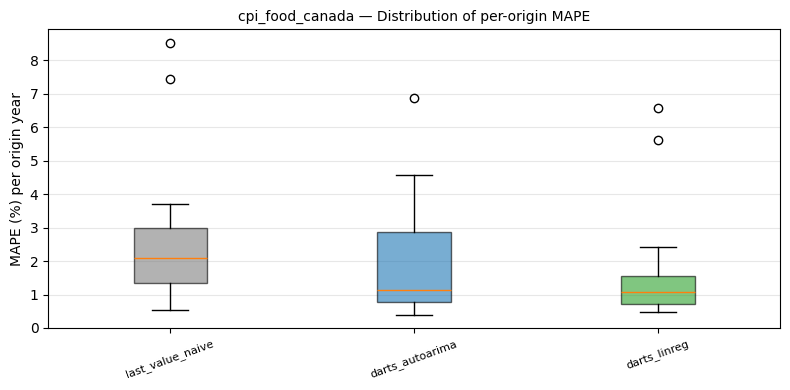

In [15]:
# Join predictions with actual values
actual_long = (
    actual_df.reset_index()[["timestamp", "value"]]
    .rename(columns={"timestamp": "forecast_date", "value": "actual"})
)
actual_long["forecast_date"] = pd.to_datetime(actual_long["forecast_date"])

preds_with_actual = all_preds_df.merge(actual_long, on="forecast_date", how="inner")
preds_with_actual["ape"] = (
    (preds_with_actual["median"] - preds_with_actual["actual"]).abs()
    / preds_with_actual["actual"].abs()
    * 100
)

# Mean APE per (predictor, origin_year)
mape_by_origin = preds_with_actual.groupby(["predictor_id", "origin_year"])["ape"].mean()
mape_pivot = mape_by_origin.unstack("predictor_id").round(3)
mape_pivot.loc["MEAN"] = mape_pivot.mean()

print("=== Mean APE (%) per origin year (lower is better) ===")
print(mape_pivot.to_string())

# Box plot of per-origin MAPE distribution
fig, ax = plt.subplots(figsize=(8, 4))
pid_list = list(PREDICTOR_COLORS.keys())
data = [mape_by_origin[pid].dropna().values for pid in pid_list if pid in mape_by_origin]
colors_list = [PREDICTOR_COLORS[pid] for pid in pid_list if pid in mape_by_origin]
labels_list = [pid for pid in pid_list if pid in mape_by_origin]

bp = ax.boxplot(data, patch_artist=True, tick_labels=labels_list)
for patch, color in zip(bp["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("MAPE (%) per origin year", fontsize=10)
ax.set_title(f"{CATEGORY_ID} — Distribution of per-origin MAPE", fontsize=10)
ax.tick_params(axis="x", labelrotation=20, labelsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Latest origin — YoY prediction range

Using the **best-performing predictor** (lowest mean CRPS), report the CFPR-style
avg/avg YoY prediction for the most recent origin (July 2024 → forecast year 2025).

In [16]:
# Best predictor by mean CRPS
best_pid = min(backtest_results, key=lambda p: backtest_results[p].mean_crps)
print(f"Best predictor: {best_pid} (mean CRPS = {backtest_results[best_pid].mean_crps:.4f})")

# Latest origin
latest_yoy_df = yoy_by_predictor[best_pid]
if latest_yoy_df.empty:
    print("No avg/avg YoY computed — check trajectory horizons and data availability.")
else:
    latest = latest_yoy_df.sort_values("origin_year").iloc[-1]
    forecast_year = int(latest["origin_year"]) + 1

    print(f"\nOrigin: July {int(latest['origin_year'])}  →  Forecast year: {forecast_year}")
    print(f"  Observed avg CPI {int(latest['origin_year'])}: {latest['actual_avg_y0']:.2f}")
    print(f"  Predicted avg CPI {forecast_year} (median): {latest['predicted_avg_y1']:.2f}")
    print(f"")
    print(f"  Avg/avg YoY prediction ({best_pid}):")
    print(f"    Median : {latest['yoy_median']*100:+.1f}%")
    print(f"    50% CI : {latest['yoy_q25']*100:+.1f}% to {latest['yoy_q75']*100:+.1f}%")
    print(f"    90% CI : {latest['yoy_q05']*100:+.1f}% to {latest['yoy_q95']*100:+.1f}%")
    if not pd.isna(latest['actual_yoy']):
        print(f"    Actual : {latest['actual_yoy']*100:+.1f}%")

Best predictor: darts_linreg (mean CRPS = 2.2599)

Origin: July 2024  →  Forecast year: 2025
  Observed avg CPI 2024: 189.29
  Predicted avg CPI 2025 (median): 194.40

  Avg/avg YoY prediction (darts_linreg):
    Median : +2.7%
    50% CI : +1.4% to +4.1%
    90% CI : -0.1% to +7.1%
    Actual : +3.2%


---
## 13. Protected evaluation

The reference eval spec covers Jul 2021–Jul 2024 (4 held-out origins).  Each
`multi_evaluate()` call counts as **one run** against the 5-run budget.  Use
this sparingly — only when you have a predictor you genuinely believe in.

> The eval spec uses `horizons: [18]` (single outermost step) to produce a
> comparable single-number CRPS. For the full trajectory eval, you would
> modify the spec or load it and override horizons.


In [17]:
EVAL_SPEC_PATH = ROOT / "reference_specs" / "food_cpi" / "food_cpi_18m_eval.yaml"
EVAL_RUNS_PATH = Path("eval_runs.yaml")  # stored alongside notebook

with open(EVAL_SPEC_PATH) as f:
    full_eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

# Subset to the selected category only
eval_spec = full_eval_spec.model_copy(
    update={"tasks": [t for t in full_eval_spec.tasks if t.target_series_id == CATEGORY_ID]}
)

print(f"Eval spec: {eval_spec.spec_id}")
print(f"Category : {CATEGORY_ID}")
print(f"Origins  : {len(eval_spec.tasks[0].horizons)}-horizon eval at {len(eval_spec.specs())} spec(s)")

tracker = EvalTracker(EVAL_RUNS_PATH)
runs_used = tracker.runs_for(eval_spec.spec_id)
max_runs = eval_spec.max_runs or "unlimited"
print(f"Budget   : {runs_used} / {max_runs} runs used")

Eval spec: food_cpi_18m_eval
Category : cpi_food_canada
Origins  : 1-horizon eval at 1 spec(s)
Budget   : 1 / 5 runs used


In [18]:
# ── Uncomment to run the protected evaluation ────────────────────────────────
# eval_predictor = backtest_results  # or a specific predictor instance
#
# best_predictor = next(p for p in predictors if p.predictor_id == best_pid)
# eval_results = multi_evaluate(
#     predictor=best_predictor,
#     spec=eval_spec,
#     data_service=svc,
#     tracker=tracker,
# )
# for task_id, r in eval_results.items():
#     print(f"  {task_id}: mean CRPS = {r.mean_crps:.4f}  (run {r.run_number}/{max_runs})")